In [ ]:
import numpy as np
from matplotlib import pyplot as plt
#

# Time solver
Solve in time the dynamics
$$\partial_t h = \partial_x Q \partial_x \Pi$$
$$\Pi = -\Delta h+\partial_h W$$
$$Q=h^3/3\eta$$
$$W=A(\chi)w(h);\quad \chi = \epsilon x$$

There is no bulk force, while
$$A=A_0+\nabla_{\chi}A \cdot \chi$$
And the inhomogenity is activated at time $t>t_0$ to leave the system the time to converge to the equilibrium state from the initial condition
$$A_0 = 1; \nabla_{\chi}A=1$$

In [13]:
eps = 0.001
ha = 0.5

eta = 1
A0 = 1
grad_chiA = 1

t0 = 1e3    # At this time driving is turned ON
def A(x):
    return A0+grad_chiA*float(eps)*x

In [14]:
# Time solver
%run -i time_solver.py $eps

# Measure $h_0^{out}$ and $\nabla_{\chi}h_0^{out}$

In the absence of driving and in the limit of large droplets, where $h_0^{out}=h_a+\delta h_0^{out}$
$$\delta h_0^{out}= \frac{w(h_{max})-w(h_a)}{h_{max}-h_a}w''(h_a)^{-1}+O((\delta h_0^{out})^2)$$
And as in this limit
$$\partial_h W_0^{out}=A(\chi_*)w''(h_a)\delta h_0^{out}$$
$$\partial_h W_0^{out}=A(\chi_*)\frac{w(h_{max})-w(h_a)}{h_{max}-h_a}$$
$$\partial_h W_0^{out}(A(\chi_*), h_0^{out})$$

For $\nabla_{\chi}h_0^{out}$, this is the same on both sides of the droplet and so we measure it during the time simulation. We use a test function $\phi$ that is 1 close to the boundaries and zero outside, such that $\int h(x)\phi(x) dx \alpha \nabla_{\chi}h_0^{out}$ where the multiplication factor is the support of $\phi$. 

In [15]:
# Read hmax and xmax

import glob

files = sorted(glob.glob("time_solver/domain/domain_*.txt"))

times = []
h_max_list = []
x_at_hmax = []

for file in files:
    # --- Read header line ---
    with open(file, "r") as f:
        header = f.readline()
    
    # Extract time
    # "# coordinate_x h p @time=353.0"
    time_val = float(header.split("@time=")[-1])
    
    # --- Read data with numpy ---
    data = np.loadtxt(file)   # automatically skips lines starting with '#'
    data = np.atleast_2d(data)
    
    x = data[:, 0]
    h = data[:, 1]
    
    # --- Find maximum ---
    idx = np.argmax(h)
    
    times.append(time_val)
    h_max_list.append(h[idx])
    x_at_hmax.append(x[idx])

# Convert to arrays
times = np.array(times)
h_max_list = np.array(h_max_list)
x_at_hmax = np.array(x_at_hmax)

In [16]:
# Compute h0out and dWh0out
def wetting_pot(h):
        return (ha**3/5*h**(-5) - 1/2*h**(-2))
def dwetting_pot(h):
        return (- ha**3*h**(-6) + h**(-3))
def ddwetting_pot(h):
        return (7*ha**3*h**(-7) - 3*h**(-4))
h0outs = ha + (wetting_pot(h_max_list)-wetting_pot(ha))/(h_max_list-ha)*(1/(ddwetting_pot(ha)))
As=A(x_at_hmax)

dW0outs = A(x_at_hmax)*(wetting_pot(h_max_list)-wetting_pot(ha))/(h_max_list-ha) #h0in is paramterized by this number only!

In [17]:
# Read grad_x h0out in the Time simulation
time, grad_x_h0out = np.loadtxt(
    "time_solver/obs.txt",
    skiprows=1,
    unpack=True
)

# Solve $h_0^{in}$ from $h_0^{out}$ (for each time-step)
As I cannot make sol of pyoomph to converge on
$$-\Delta h_0^{in} +\partial_h W_0^{in} = \partial_h W_0^{out}$$
I look for the stationary states of 
$$-\Delta h_0^{in}+\partial_h W_0^{in} = 0$$
with a mass constrain, that is equivalent to solve the previous equation where $\partial_h W_0^{out}$ is the **Lagrange multiplier** for the mass

The advantage is that you can do continuation in the concentration (volume). And starting from the homogeneous state with a small mass (such that it is unstable) you will find a bp where you can follow the branch with a droplet.

Once the droplet branch is found, we measure along it $\partial_h W_0^{out}$ (the lagrange multiplier of the mass) and the integrals $\Omega, I, K$.
Then we can extrapolate the integrals as function of $\partial_h W_0^{out}$.

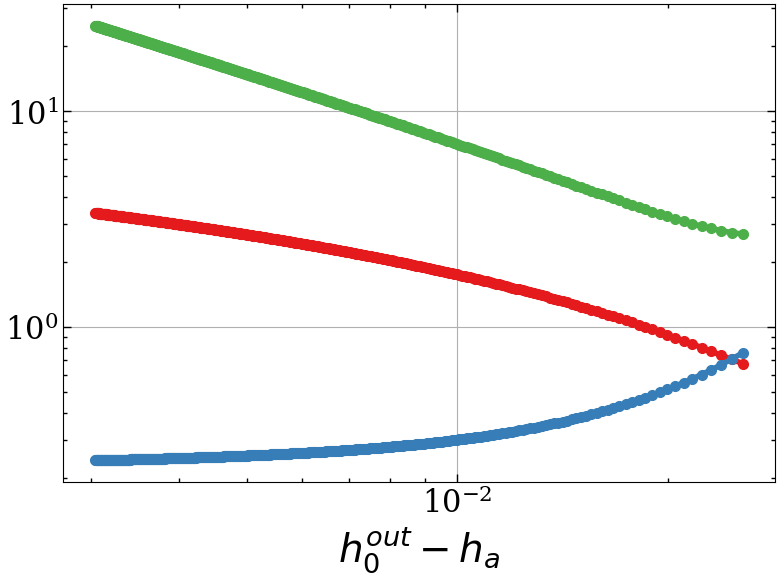

In [ ]:
# Read the integrals as a function of h0out from the pde2path continuatiom
data = np.loadtxt(
    "1D_c0_continuation_16_04_26.txt",
    delimiter=',',
    unpack=True
)
numrows = len(data[0,:])
K = data[1:, numrows-1]
I = data[1:, numrows-2]
Omega = data[1:, numrows-3]
h0out_cont = data[1:, numrows-4]
dWout_cont = data[1:, numrows-5]
c0 = data[1:, numrows-6]

#plt.plot(h0out_cont-ha,K,'.-')
#plt.plot(h0out_cont-ha,I,'.-')
#plt.loglog(h0out_cont-ha,Omega,'.-')
#plt.xlabel('$h_0^{out}-h_a$')
#plt.grid()

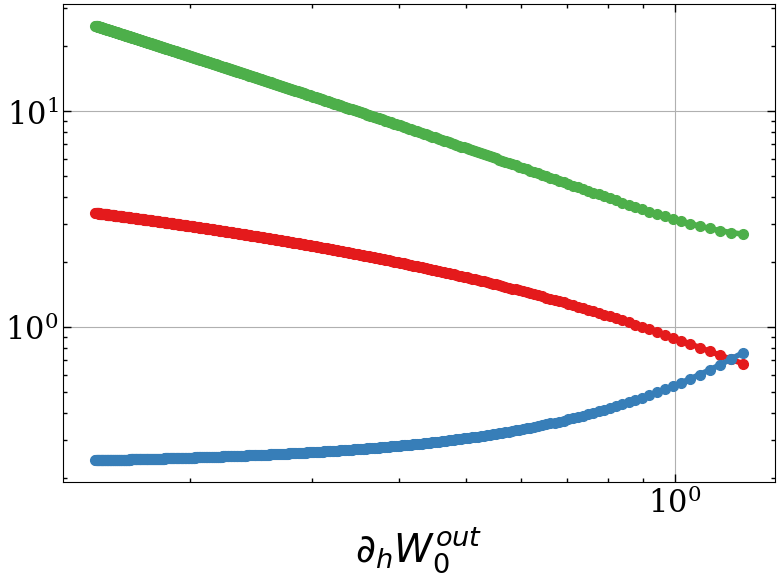

In [23]:
plt.plot(dWout_cont,K,'.-')
plt.plot(dWout_cont,I,'.-')
plt.loglog(dWout_cont,Omega,'.-')
plt.xlabel('$\partial_h W_0^{out}$')
plt.grid()

# Validation of the model

$$K= \int \frac{(\hat{h}_{0}^{in})^2}{(h_{0}^{in})^3}d\xi;\quad \hat{\Omega}=\int d\xi \hat{w}_{0}^{in};\quad m=\int d\xi \hat{h}_{0}^{in};\quad I=(h_{0}^{out})^3\int d\xi\frac{ \hat{h}_{0}^{in}}{(h_{0}^{in})^3}$$

$$3\eta K v_{1}= \nabla_{\chi} A(w'_{out}I-\hat{\Omega})+c(m-I)+Iw''_{out}A(\chi_{*})\nabla_{\chi}A(\chi_{*})$$
In our case $c=0$ as there is no bulk force

In [19]:
# Extrapolate the integrals I, K , Omega for the measured values of dW0out in the Time simulation taking the average between the closest values
# to compute the predicted value of v1 (for each time-step of the time simulation)
v1s = []
for j in np.arange(0,len(h0outs)):
    # Measurements from Time simulation
    h0out = h0outs[j]
    dW0out = dW0outs[j]
    A_droplet = As[j]
    nabla_x_h0out = grad_x_h0out[j]

    # Extrapolate the integrals I,K,Omega corresponding to the value of dW0out measured in the time simulation
    i = 1
    dW0out_temp = dWout_cont[-i]
    while dW0out > dW0out_temp and i < len(dWout_cont):
        i = i+1
        dW0out_temp = dWout_cont[-i]
    #dW0out_temp = (dW0out_temp + dWout_cont[-i+1])/2
    I_temp = (I[-i] + I[-i+1])/2
    K_temp = (K[-i] + K[-i+1])/2
    Omega_temp = (Omega[-i] + Omega[-i+1])/2
    # Here we consider only an inhomogenity and NOT a bulk force
    #nabla_x_h0out = 0
    v1 = 1/(3*eta*K_temp)*((-Omega_temp+dwetting_pot(h0out)*I_temp)*grad_chiA+I_temp*ddwetting_pot(h0out)*A_droplet*nabla_x_h0out/eps)
    v1s.append(v1)


Text(0, 0.5, '$x_{max}$')

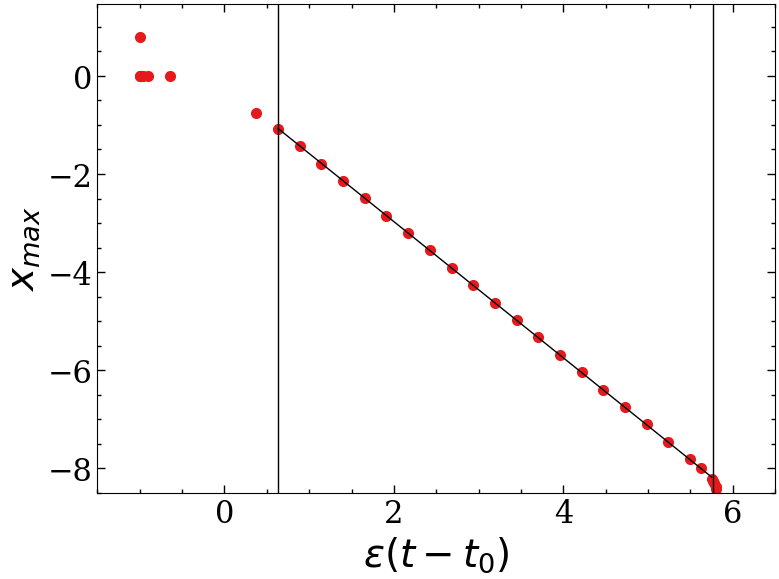

In [20]:
from matplotlib import pyplot as plt

# Measure of droplet position in the Time simulation
plt.plot((times-t0)*eps, x_at_hmax,'.')
imin = 10
imax = 32
plt.axvline((times[imin]-t0)*eps,color='black',lw='1')
plt.axvline((times[imax]-t0)*eps,color='black',lw='1')
tt = (times[imin:imax]-t0)*eps
xx = x_at_hmax[imin:imax]
c = np.polyfit(tt, xx, deg=1)
v1_time_simul = c[0]
plt.plot(tt, c[1]+c[0]*tt,color='black',lw='1')
plt.ylim(bottom=-8.5)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$x_{max}$')

Text(0, 0.5, '$v_{1}$')

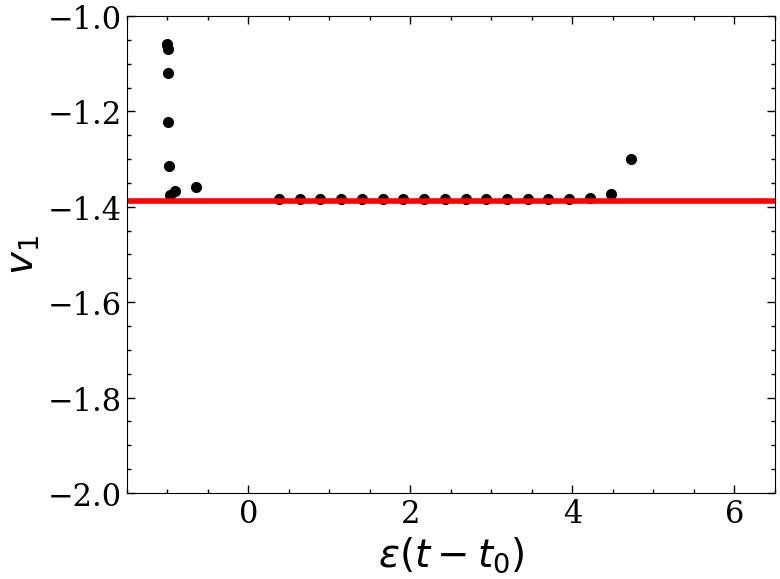

In [ ]:
# Compare simulation with model
plt.plot(eps*(times-t0), v1s,'.',color='black')
plt.axhline(v1_time_simul,color='red')
plt.ylim(top=-1, bottom=-2)
plt.xlim(right=6.5)
plt.xlabel('$\epsilon (t-t_0)$')
plt.ylabel('$v_{1}$')